In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving HR_comma_sep.csv to HR_comma_sep.csv
Saving insurance_data.csv to insurance_data.csv
Saving iris (1).csv to iris (1).csv
Saving zoo-class-type.csv to zoo-class-type.csv
Saving zoo-data.csv to zoo-data.csv
User uploaded file "HR_comma_sep.csv" with length 566785 bytes
User uploaded file "insurance_data.csv" with length 155 bytes
User uploaded file "iris (1).csv" with length 4617 bytes
User uploaded file "zoo-class-type.csv" with length 963 bytes
User uploaded file "zoo-data.csv" with length 4368 bytes


Saving insurance_data.csv to insurance_data (1).csv
   age  bought_insurance
0   22                 0
1   25                 0
2   47                 1
3   52                 0
4   46                 1


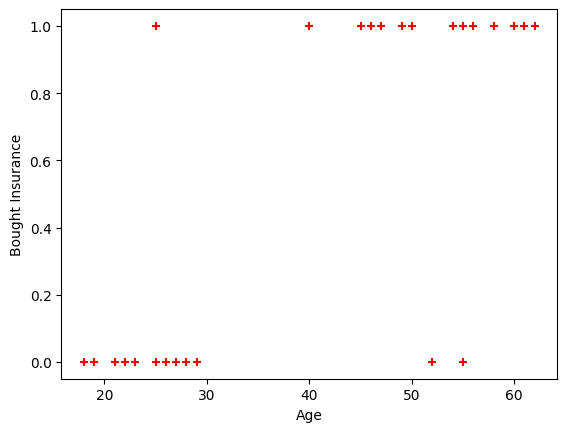

Predictions: [1 1 0]
Actual: [1 1 0]
Accuracy: 1.0
Prediction Probability:
[[0.06470655 0.93529345]
 [0.10327333 0.89672667]
 [0.92775258 0.07224742]]
Prediction for age 60: [1]
Coefficient: [[0.1274065]]
Intercept: [-4.97339194]
Probability for age 35: 0.3742177776690936


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Upload CSV file in Colab
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("insurance_data.csv")

print(df.head())

# Plot data
plt.scatter(df.age, df.bought_insurance, marker='+', color='red')
plt.xlabel("Age")
plt.ylabel("Bought Insurance")
plt.show()

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    df[['age']], df.bought_insurance, train_size=0.9, random_state=10
)

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
y_predicted = model.predict(X_test)

print("Predictions:", y_predicted)
print("Actual:", y_test.values)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

# Probability
print("Prediction Probability:")
print(model.predict_proba(X_test))

# Predict for age = 60
print("Prediction for age 60:", model.predict([[60]]))

# Model parameters
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def prediction_function(age):
    z = model.coef_[0][0] * age + model.intercept_[0]
    y = sigmoid(z)
    return y

# Example prediction
age = 35
print("Probability for age 35:", prediction_function(age))

Saving iris (1).csv to iris (1) (2).csv
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


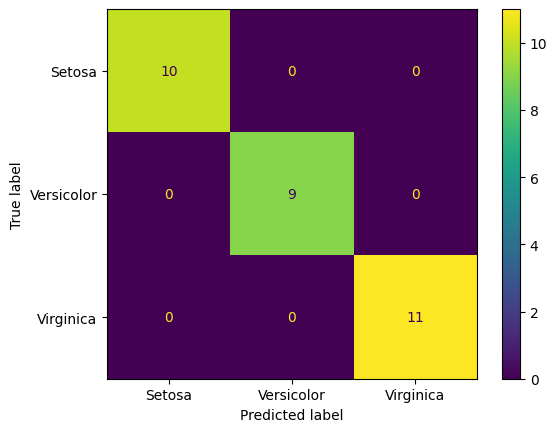

In [4]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import metrics

# Upload CSV file
from google.colab import files
uploaded = files.upload()

# Load dataset
iris = pd.read_csv("iris (1).csv")

print(iris.head())

# Features and target
X = iris.drop('species', axis=1)
y = iris['species']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion matrix
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)

cm_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix,
    display_labels=["Setosa", "Versicolor", "Virginica"]
)

cm_display.plot()
plt.show()